In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv("./data-v1/XSP-windows.csv")
df = df[df["days_to_expiry"] > 365]

df['strike_group'] = pd.qcut(df['strike_pct'], q=25, labels=False)
grouped_avg = df.groupby('strike_group').mean(numeric_only=True)
grouped_avg[["days_to_expiry", "strike_pct", "good_apr_pct", "bad_apr_pct"]]

,days_to_expiry,strike_pct,good_apr_pct,bad_apr_pct
strike_group,,,,
0,504.6484,51.0231,0.0013,0.5324
1,505.5872,59.7790,0.0069,0.6613
2,503.0872,64.5676,0.0372,0.9292
3,487.1279,69.8782,0.0711,1.0801
4,448.0367,75.0646,0.2131,1.2591
5,436.6422,78.6669,0.2316,1.4308
6,425.5909,81.3802,0.4392,1.5439
7,424.2442,83.8877,0.6583,1.4846
8,423.5917,85.9683,0.8151,1.6114


In [15]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv("./data-v1/XSP-windows.csv")
df = df[(df["days_to_expiry"] < 365) & (df["days_to_expiry"] > 180)]

df['strike_group'] = pd.qcut(df['strike_pct'], q=25, labels=False)
grouped_avg = df.groupby('strike_group').mean(numeric_only=True)
grouped_avg[["days_to_expiry", "strike_pct", "good_apr_pct", "bad_apr_pct"]]

,days_to_expiry,strike_pct,good_apr_pct,bad_apr_pct
strike_group,,,,
0,273.8830,52.4074,0.0031,0.4272
1,272.9402,64.5850,0.0234,0.7591
2,267.8210,70.8963,0.0842,0.9827
3,260.2406,75.2104,0.1954,1.1423
4,266.2598,78.1181,0.3443,1.2833
5,264.8633,80.1353,0.4507,1.3802
6,266.3961,81.8940,0.5552,1.3344
7,266.4220,83.5248,0.6652,1.4482
8,258.1729,84.8669,0.7458,1.5607


/tmp/ipykernel_38186/4199268685.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['maturity_bracket', 'strike_group'])


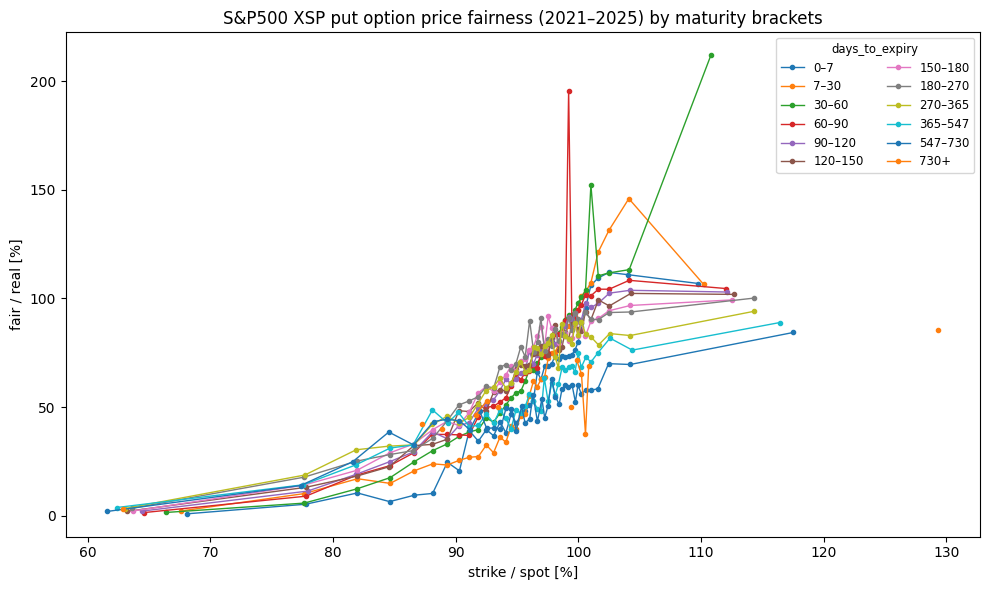

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Display settings (unchanged)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# --- Load & basic prep ---
df = pd.read_csv("./data-v1/XSP-windows.csv")

# Assign global strike quantiles ONCE so groups are consistent across all brackets
df = df.copy()
df['strike_group'] = pd.qcut(df['strike_pct'], q=40, labels=False, duplicates='drop')

# --- Define maturity brackets ---
# Boundaries: 0, 7, 30, 60, 90, 120, 150, 180, 270, 365, 547, 730, inf
edges = [0, 7, 30, 60, 90, 120, 150, 180, 270, 365, 547, 730, np.inf]
labels = []
for i in range(len(edges) - 1):
    lo, hi = edges[i], edges[i+1]
    if np.isinf(hi):
        labels.append(f"{int(lo)}+")
    else:
        labels.append(f"{int(lo)}–{int(hi)}")

# Bin the maturities
df['maturity_bracket'] = pd.cut(df['days_to_expiry'], bins=edges, labels=labels, right=False, include_lowest=True)

# Optional: drop rows that didn't land in any bracket (NaNs due to missing or negative maturities)
df = df.dropna(subset=['maturity_bracket', 'strike_group'])

# --- Compute per-bracket grouped means ---
# We'll compute mean strike_pct and fair_pct per strike_group within each bracket
grouped = (
    df.groupby(['maturity_bracket', 'strike_group'])
      .agg(strike_pct_mean=('strike_pct', 'mean'),
           fair_pct_mean=('fair_pct', 'mean'),
           n=('fair_pct', 'size'))
      .reset_index()
)

# --- Plot ---
plt.figure(figsize=(10, 6))

# Sort brackets in our chosen order
bracket_order = labels  # already ordered by edges

# For each bracket, plot fair/real vs strike/spot over the 40 quantile bins
for br in bracket_order:
    sub = grouped[grouped['maturity_bracket'] == br].sort_values('strike_group')
    # Skip empty / tiny brackets
    if sub.empty or sub['n'].sum() == 0:
        continue
    plt.plot(sub['strike_pct_mean'], sub['fair_pct_mean'], marker='o', linewidth=1, markersize=3, label=str(br))

plt.xlabel("strike / spot [%]")
plt.ylabel("fair / real [%]")
plt.title("S&P500 XSP put option price fairness (2021–2025) by maturity brackets")
plt.legend(title="days_to_expiry", fontsize='small', title_fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv("./data-v1/XSP-windows.csv")
df[["days_to_expiry", "option_price", "bs_price", "strike_pct", "good_apr_pct", "bad_apr_pct"]].head()

,days_to_expiry,option_price,bs_price,strike_pct,good_apr_pct,bad_apr_pct
0,5,0.01,0.000000e+00,90.735327,0.000000e+00,0.160617
1,5,0.05,7.257142e-10,94.030799,1.164622e-08,0.805631
2,5,0.14,2.852736e-03,97.106573,4.579375e-02,2.225133
3,5,0.26,1.178184e-02,97.545969,1.892626e-01,4.062922
4,5,0.33,4.107414e-02,97.985365,6.613443e-01,4.744603


In [ ]:
# partitioned by days to expiry, quantiles for strike pct
# days_to_expiry strike_pct good_apr_pct bad_apr_pct

# (fair / real) VS (strike / spot) by days to expiry

# total_pct VS good_pct where different strikes are one graph, multiple for different days to expiry